<a href="https://colab.research.google.com/github/claudio1975/Storm_Events/blob/main/11_Global_Comparison.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Global Comparison

In [ ]:
#############################################################
# COMPARISON SETUP
#############################################################

from pathlib import Path

import matplotlib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from google.colab import drive
from matplotlib.colors import LogNorm, Normalize

drive.mount("/content/drive")

RESULTS_DIR = Path("/content/drive/MyDrive/Storm_Events/global_model_results")
SPLIT_ORDER = ["train", "calibration", "test"]
POINT_METRIC_COLUMNS = ["n", "events", "D2", "RMSE", "MPD"]
GROUP_COL = "EVENT_GROUP"

PREDICTION_TARGETS = ["INJURIES", "DEATHS"]

# which models are compared, in which order, in which colour: one file each in RESULTS_DIR
MODEL_COLORS = {
    "GLM": "#1f4e79",
    "LGBM": "#e07b39",
    "LSTM": "#4c9a2a",
    "TABPFN": "#8e44ad",
    "tabular-transformer": "#ff0000",
}

COMPARISON_METRICS = ["D2", "RMSE", "MPD"]
METRIC_DIRECTION = {"D2": "high = better", "RMSE": "low = better", "MPD": "low = better"}
ALPHA_TARGET = 0.10

payloads = {name: pd.read_pickle(RESULTS_DIR / f"{name}.pkl") for name in MODEL_COLORS}
MODEL_RESULTS = {name: payload["results"] for name, payload in payloads.items()}
MODEL_LABELS = {name: payload["label"] for name, payload in payloads.items()}

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
#############################################################
# COMPARISON TABLES
#############################################################

def _stack_metrics(results, key, index_names):
    """Stacks one metrics table per target, splits ordered as they occur in
    time: train, calibration, test."""
    df = pd.concat({k: v[key] for k, v in results.items()})
    df.index.names = index_names
    df = df.reset_index()
    df["Split"] = pd.Categorical(df["Split"], categories=SPLIT_ORDER, ordered=True)

    return df.set_index(index_names).sort_index()


def point_metrics_by_target(results):
    """point metrics tables per outcome"""
    return _stack_metrics(results, "metrics", ["Target", "Split"])


def point_metrics_by_event_group(results, group_column=GROUP_COL):
    """point metrics tables per outcome and event group"""
    return _stack_metrics(results, "group_metrics", ["Target", "Split", group_column])


def _add_relative_width(summary):
    """Reads the band width against the level it is measuring.

    MeanWidth is in target units - deaths per month, injuries per day - so it
    cannot be compared across targets, views or event groups. RelWidth can:
    it is MeanWidth over MeanActual."""
    mean_actual = summary["MeanActual"]
    summary["RelWidth"] = summary["MeanWidth"] / mean_actual.where(mean_actual > 0)

    return summary


def collect_point_metrics(model_results=MODEL_RESULTS):
    frames = []
    for model_name, results in model_results.items():
        table = point_metrics_by_target(results).reset_index()
        table["Model"] = model_name
        frames.append(table)

    comparison = pd.concat(frames, ignore_index=True)

    return comparison[["Model", "Target", "Split", *POINT_METRIC_COLUMNS]].sort_values(
        ["Target", "Split", "Model"]
    )


def collect_conformal_by_target(model_results=MODEL_RESULTS, alpha_target=ALPHA_TARGET):
    rows = [
        {
            "Model": model_name,
            "Target": target,
            "Level": level_name,
            "n": len(frame),
            "Coverage": float(frame["covered"].mean()),
            "MeanActual": float(frame["actual"].mean()),
            "MeanWidth": float(frame["width"].mean()),
            "Nominal": 1.0 - alpha_target,
        }
        for model_name, results in model_results.items()
        for target, result in results.items()
        for level_name, frame in (
            ("daily", result["daily_conformal"]),
            ("monthly", result["monthly_conformal"]),
        )
    ]

    return _add_relative_width(pd.DataFrame(rows))[
        ["Model", "Target", "Level", "n", "Coverage",
         "MeanActual", "MeanWidth", "RelWidth", "Nominal"]
    ]


point_comparison = collect_point_metrics()
conformal_comparison = collect_conformal_by_target()

In [ ]:
#############################################################
# 1. POINT METRICS: MODEL x TARGET x SPLIT
#############################################################


def plot_metric_comparison(
    metrics_table=None,
    metrics=COMPARISON_METRICS,
    splits=SPLIT_ORDER,
    targets=None,
    model_colors=MODEL_COLORS,
):
    metrics_table = collect_point_metrics() if metrics_table is None else metrics_table
    targets = list(PREDICTION_TARGETS) if targets is None else list(targets)
    models = list(model_colors)

    positions = np.arange(len(targets))
    bar_width = 0.8 / len(models)

    fig, axes = plt.subplots(
        len(metrics),
        len(splits),
        figsize=(5.4 * len(splits), 3.6 * len(metrics)),
        layout="constrained",
        squeeze=False,
    )

    for row, metric in enumerate(metrics):
        for column, split in enumerate(splits):
            ax = axes[row][column]
            panel = metrics_table[metrics_table["Split"] == split]

            for index, model_name in enumerate(models):
                values = (
                    panel[panel["Model"] == model_name]
                    .set_index("Target")
                    .reindex(targets)[metric]
                    .to_numpy(dtype=float)
                )
                offset = (index - (len(models) - 1) / 2) * bar_width
                ax.bar(
                    positions + offset,
                    values,
                    width=bar_width,
                    color=model_colors[model_name],
                    edgecolor="white",
                    linewidth=0.5,
                    label=model_name if (row == 0 and column == 0) else None,
                )

                for position, value in zip(positions + offset, values):
                    if np.isnan(value):
                        ax.text(position, 0, "n/d", ha="center", va="bottom", fontsize=8, color="grey")

            if metric == "D2":
                ax.axhline(0.0, color="grey", linestyle="--", linewidth=1)
            else:
                spread = panel[metric].to_numpy(dtype=float)
                spread = spread[np.isfinite(spread) & (spread > 0)]
                if len(spread) > 0 and spread.max() / spread.min() > 50:
                    ax.set_yscale("log")
                    ax.set_ylim(spread.min() * 0.5, spread.max() * 2.0)

            ax.set_xticks(positions)
            ax.set_xticklabels([name for name in targets], rotation=20, ha="right", fontsize=9)
            ax.set_title(f"{metric} — {split} ({METRIC_DIRECTION[metric]})", fontsize=11)
            ax.set_ylabel(metric)

    axes[0][0].legend(fontsize=9, title="Model")
    fig.suptitle("Point metrics comparison by target and split", fontsize=14)
    plt.show()


#############################################################
# 2. CONFORMAL COVERAGE AND RELATIVE WIDTH BY TARGET
#############################################################

def plot_conformal_comparison(
    conformal_table=None,
    levels=("daily",),
    targets=None,
    quantities=("Coverage", "RelWidth"),
    model_colors=MODEL_COLORS,
):
    """Coverage and width per target"""
    conformal_table = collect_conformal_by_target() if conformal_table is None else conformal_table

    targets = list(PREDICTION_TARGETS) if targets is None else list(targets)
    models = list(model_colors)
    columns = [name for name in quantities if name in conformal_table.columns]

    positions = np.arange(len(targets))
    bar_width = 0.8 / len(models)
    target_labels = [name.replace("_", " ").capitalize() for name in targets]
    nominal = (
        float(conformal_table["Nominal"].iloc[0])
        if "Nominal" in conformal_table.columns
        else None
    )

    fig, axes = plt.subplots(
        len(levels),
        len(columns),
        figsize=(7.0 * len(columns), 4.4 * len(levels)),
        layout="constrained",
        squeeze=False,
    )

    for row, level_name in enumerate(levels):
        panel_source = conformal_table[conformal_table["Level"] == level_name]

        for column, quantity in enumerate(columns):
            ax = axes[row][column]

            for index, model_name in enumerate(models):
                values = (
                    panel_source[panel_source["Model"] == model_name]
                    .set_index("Target")
                    .reindex(targets)[quantity]
                    .to_numpy(dtype=float)
                )
                offset = (index - (len(models) - 1) / 2) * bar_width
                bars = ax.bar(
                    positions + offset,
                    values,
                    width=bar_width,
                    color=model_colors[model_name],
                    edgecolor="white",
                    linewidth=0.5,
                    label=model_name if (row == 0 and column == 0) else "_nolegend_",
                )
                ax.bar_label(
                    bars,
                    labels=["" if not np.isfinite(v) else f"{v:.2f}" for v in values],
                    fontsize=8,
                    padding=2,
                )

            if quantity == "Coverage":
                if nominal is not None:
                    ax.axhline(
                        nominal,
                        color="red",
                        linestyle="--",
                        linewidth=1.2,
                        label=f"nominal {nominal:.2f}" if row == 0 else "_nolegend_",
                    )
                ax.set_ylim(0.0, 1.15)
            else:
                spread = panel_source[quantity].to_numpy(dtype=float)
                spread = spread[np.isfinite(spread) & (spread > 0)]

                if len(spread) > 0:
                    if spread.max() / spread.min() > 50:
                        ax.set_yscale("log")
                    else:
                        ax.set_ylim(0.0, spread.max() * 1.20)

            ax.set_xticks(positions)
            ax.set_xticklabels(target_labels, rotation=20, ha="right", fontsize=9)
            ax.set_title(f"{quantity}", fontsize=11)
            ax.set_ylabel(quantity)
            ax.grid(axis="y", alpha=0.25, linewidth=0.6)
            ax.set_axisbelow(True)

    handles, labels = axes[0][0].get_legend_handles_labels()
    fig.legend(handles, labels, loc="outside lower center", ncols=len(models) + 1, fontsize=9)
    fig.suptitle("Conformal intervals: coverage and relative width by target", fontsize=14)
    plt.show()


# ==============================================================================
# 3. POINT METRICS HEATMAP BY EVENT GROUP AND TARGET
# ==============================================================================

HEATMAP_METRICS = {
    "D2": ("D2 (high = better)", "RdYlGn", "{:.2f}"),
    "RMSE": ("RMSE (low = better)", "YlOrRd", "{:.3g}"),
    "MPD": ("MPD (low = better)", "YlOrRd", "{:.3g}"),
}

D2_FLOOR, D2_CEILING = -1.0, 1.0


def _colour_norm(panel, metric):
    """Colour normalisation for one heatmap panel.

    D2  -> symmetric linear scale on [-1, 1], so 0 sits on the neutral midpoint
           of RdYlGn. Values outside the range are clipped for colour only.
    RMSE / MPD -> ONE logarithmic scale shared by the whole panel, so the colour
           reads the score itself and stays comparable across targets.
    """
    if metric == "D2":
        return Normalize(vmin=D2_FLOOR, vmax=D2_CEILING)

    values = panel.to_numpy(dtype=float)
    positive = values[np.isfinite(values) & (values > 0)]

    if positive.size == 0:
        return Normalize(vmin=0.0, vmax=1.0)

    low, high = positive.min(), positive.max()
    high = high if high > low else low * 10.0

    return LogNorm(vmin=low, vmax=high)


def _text_colour(cmap, norm, value):
    """Black or white label, decided by the luminance of the cell colour."""
    if not np.isfinite(value):
        return "grey"

    red, green, blue, _ = cmap(norm(value))
    luminance = 0.299 * red + 0.587 * green + 0.114 * blue

    return "white" if luminance < 0.5 else "black"


def plot_point_metrics_heatmap(
    model,
    metrics=None,
    targets=None,
    group_column=GROUP_COL,
    split="test",
):
    """Event group x target heatmap of the point metrics, test split only."""
    label = MODEL_LABELS[model]
    metrics = list(HEATMAP_METRICS) if metrics is None else list(metrics)
    targets = list(PREDICTION_TARGETS) if targets is None else list(targets)

    table = point_metrics_by_event_group(MODEL_RESULTS[model], group_column=group_column)
    table = table[table.index.get_level_values("Split") == split]

    if table.empty:
        raise ValueError(f"no {split} rows in the group metrics table")

    table = table.droplevel("Split")

    group_order = (
        table.groupby(group_column, observed=True)["events"]
        .sum()
        .sort_values(ascending=False)
        .index
    )
    target_labels = [name.replace("_", " ").capitalize() for name in targets]

    fig, axes = plt.subplots(
        1,
        len(metrics),
        figsize=(4.6 * len(metrics), 0.42 * len(group_order) + 2.6),
        layout="constrained",
        squeeze=False,
    )

    for column, metric in enumerate(metrics):
        ax = axes[0][column]
        title, colormap, number_format = HEATMAP_METRICS[metric]

        panel = (
            table[metric]
            .unstack("Target")
            .reindex(index=group_order, columns=targets)
            .astype(float)
        )

        norm = _colour_norm(panel, metric)
        cmap = matplotlib.colormaps[colormap].copy()
        cmap.set_bad("#e8e8e8")

        drawn = panel.clip(lower=D2_FLOOR, upper=D2_CEILING) if metric == "D2" else panel

        image = ax.imshow(drawn.to_numpy(), cmap=cmap, norm=norm, aspect="auto")

        for row_index, group_name in enumerate(panel.index):
            for column_index, target in enumerate(panel.columns):
                value = panel.loc[group_name, target]

                if not np.isfinite(value):
                    ax.text(column_index, row_index, "n/d", ha="center", va="center",
                            fontsize=7, color="grey")
                    continue

                ax.text(
                    column_index,
                    row_index,
                    number_format.format(value),
                    ha="center",
                    va="center",
                    fontsize=7,
                    color=_text_colour(cmap, norm, drawn.loc[group_name, target]),
                )

        ax.set_xticks(np.arange(len(targets)))
        ax.set_xticklabels(target_labels, rotation=30, ha="right", fontsize=8)
        ax.set_yticks(np.arange(len(panel.index)))
        ax.set_yticklabels([str(name).replace("_", " ") for name in panel.index], fontsize=8)
        ax.set_title(title, fontsize=11)

        ax.set_xticks(np.arange(len(targets) + 1) - 0.5, minor=True)
        ax.set_yticks(np.arange(len(panel.index) + 1) - 0.5, minor=True)
        ax.grid(which="minor", color="white", linewidth=1.0)
        ax.tick_params(which="minor", length=0)

        bar = fig.colorbar(image, ax=ax, fraction=0.045, pad=0.02)
        bar.set_label(
            f"D2, clipped to [{D2_FLOOR:g}, {D2_CEILING:g}]" if metric == "D2"
            else f"{metric}, actual units, log scale",
            fontsize=8,
        )
        bar.ax.tick_params(labelsize=7)

    fig.suptitle(
        f"Point metrics by event group and target — {split} split — {label}", fontsize=14
    )
    plt.show()

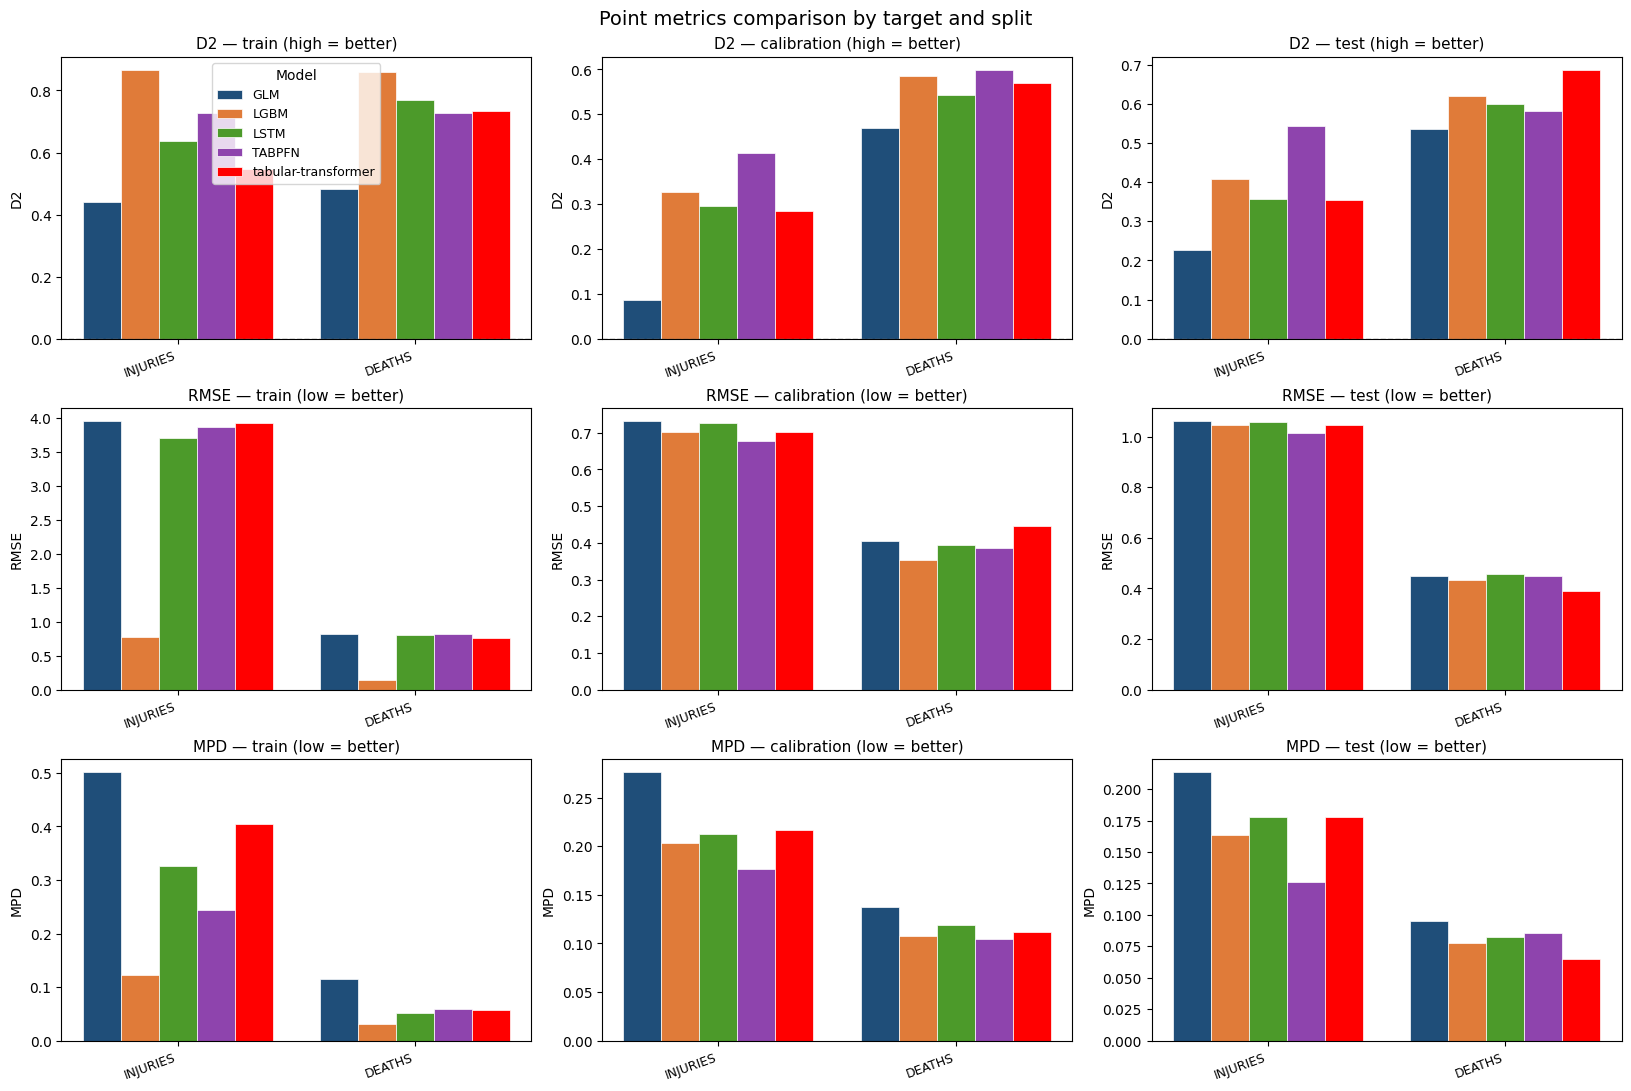

In [ ]:
plot_metric_comparison(point_comparison)



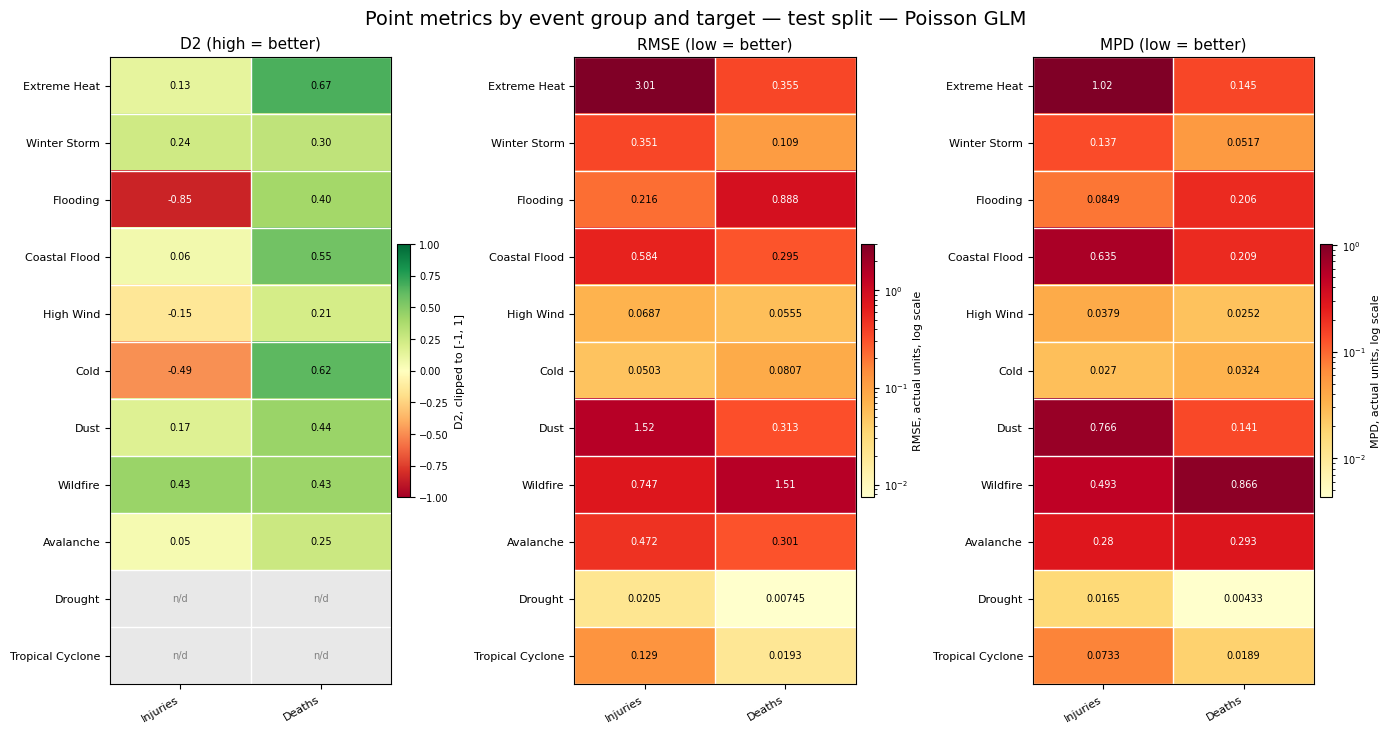

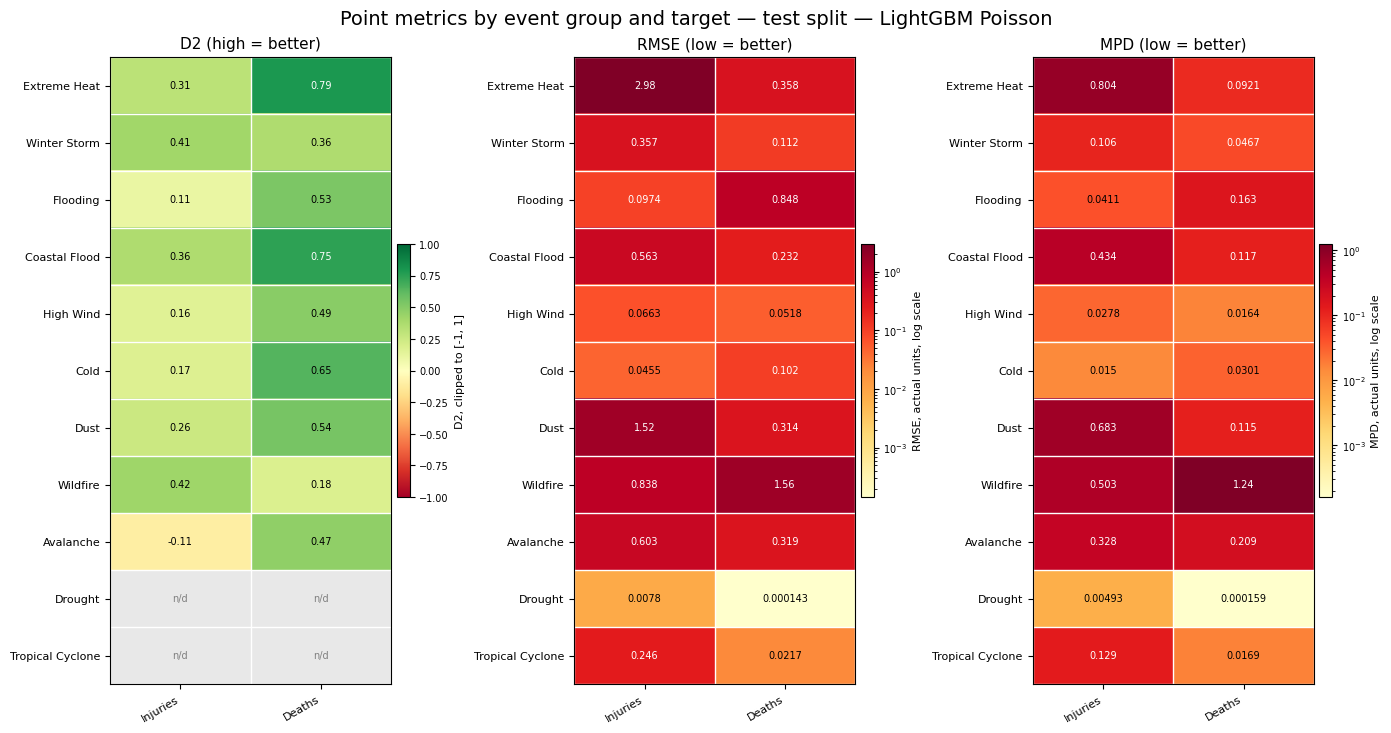

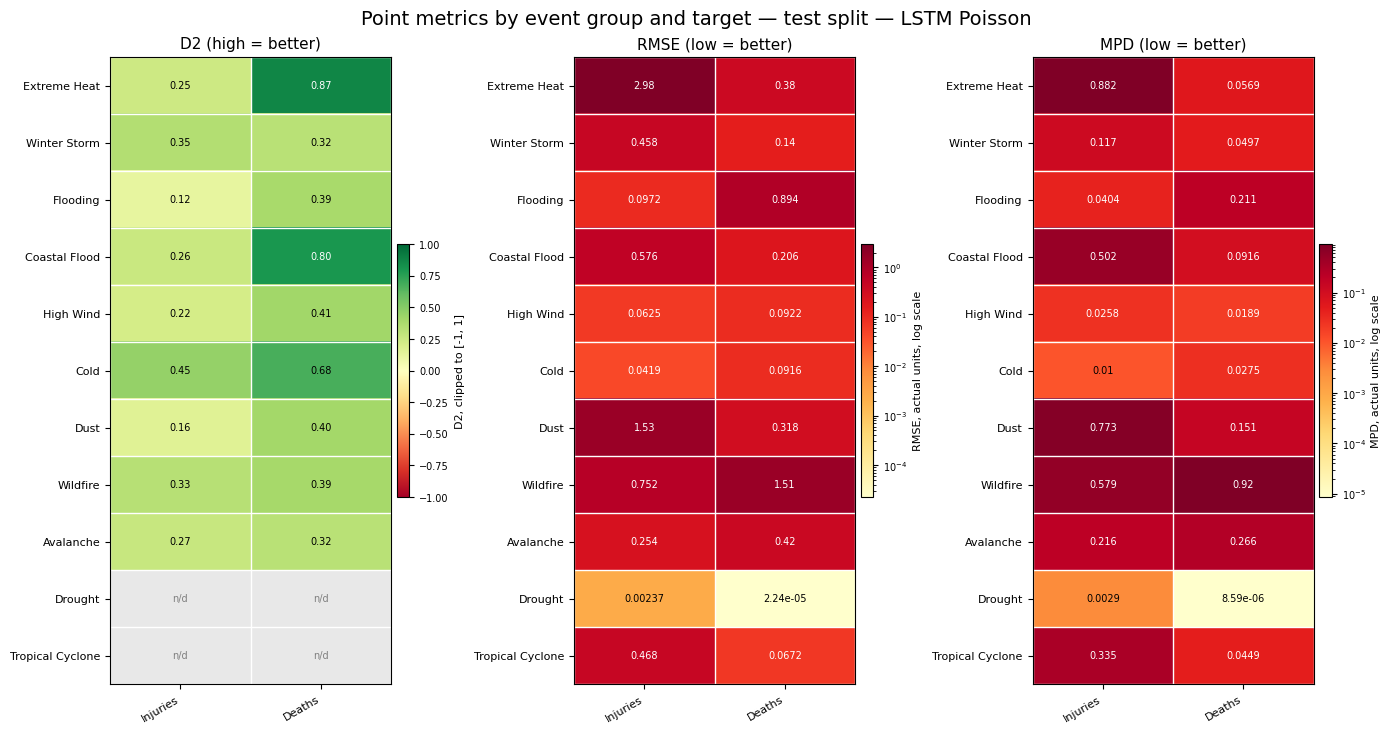

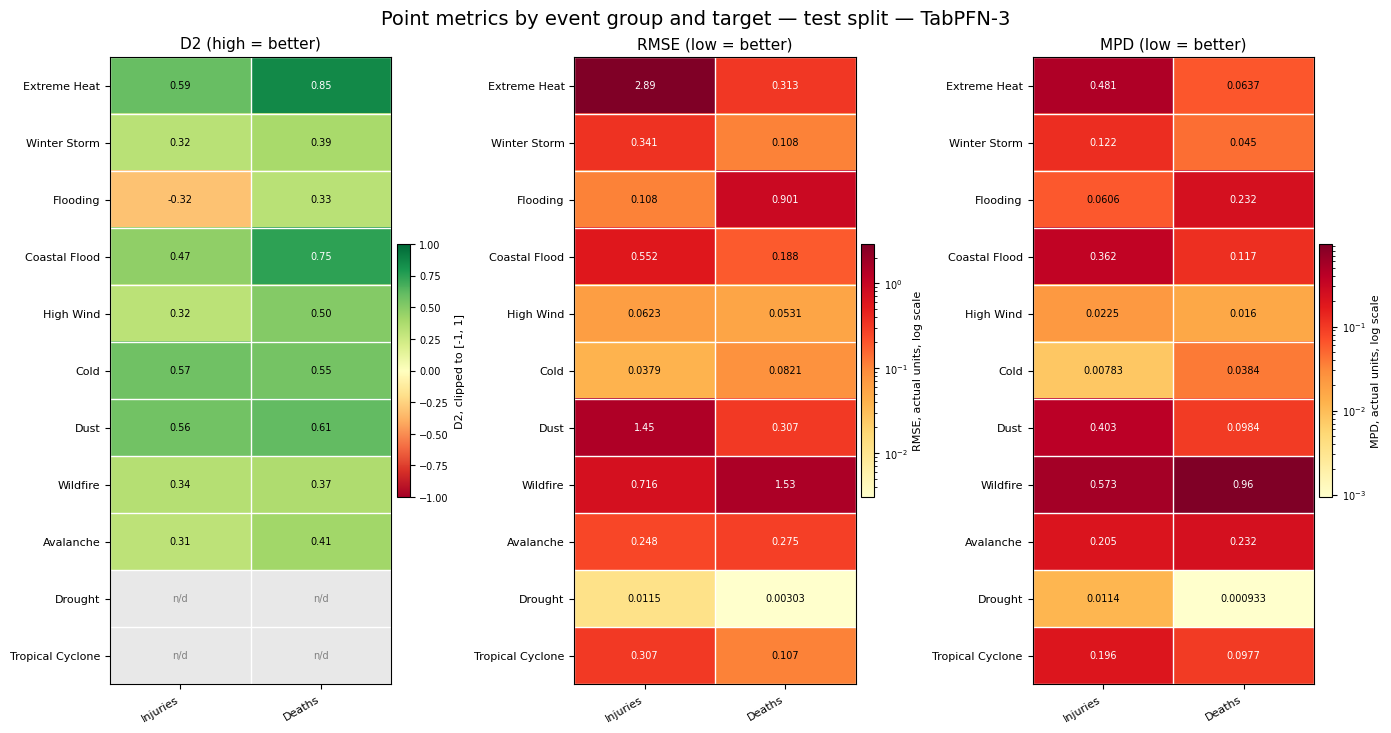

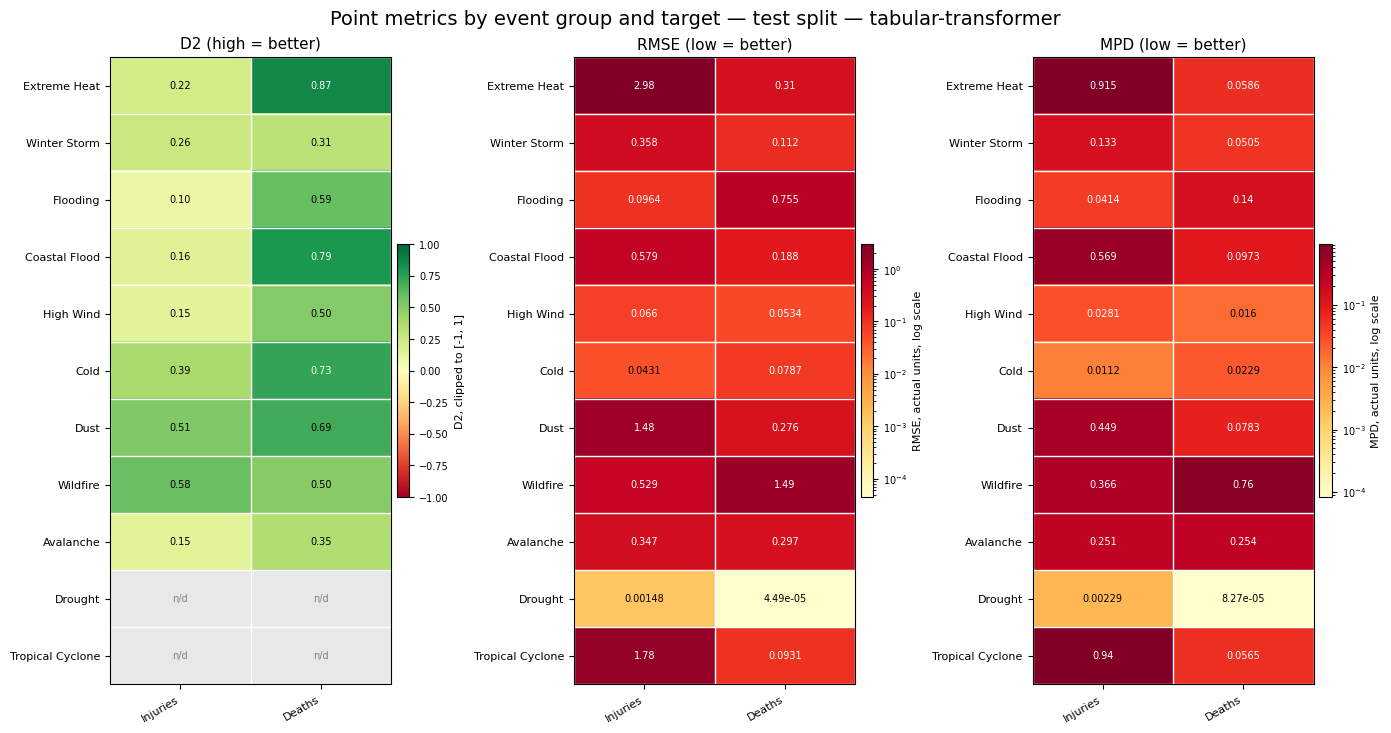

In [ ]:
for model in MODEL_COLORS:
    plot_point_metrics_heatmap(model)



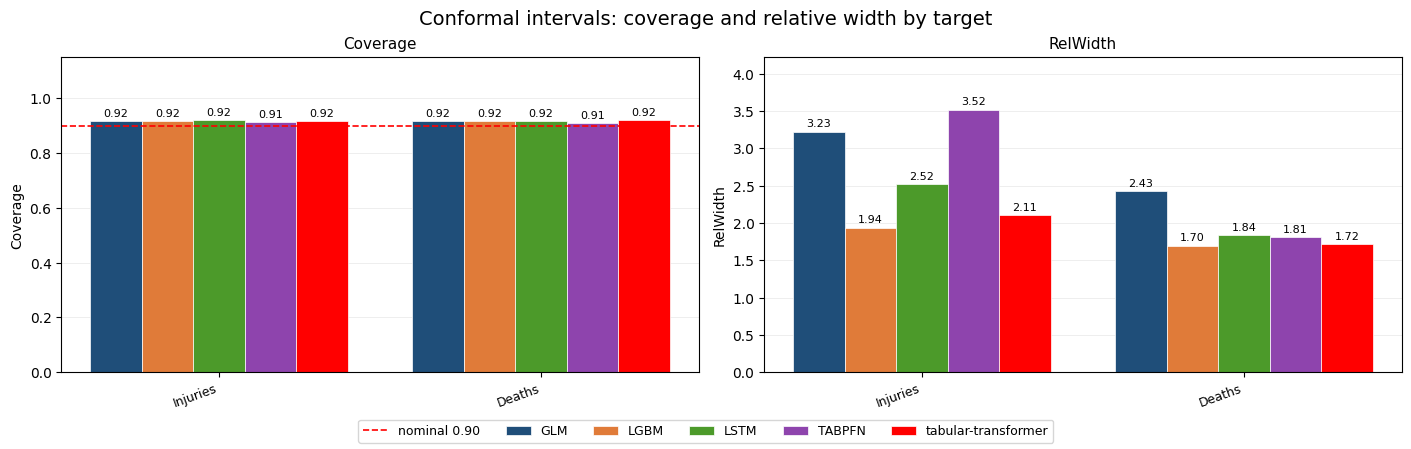

In [ ]:
plot_conformal_comparison(conformal_comparison)